Step 1

In [2]:
import pandas as pd

# --- Folders for the two training drones ---
folders = {
    "331": {"path": "C:/Hackathon-predictive-maintenance-challenge/data/crashes/331c/", "label": 0},
    "1625": {"path": "C:/Hackathon-predictive-maintenance-challenge/data/successful/1625/", "label": 1}
}

# Attributes to load
attributes = [
    "ACT_AILERON_LEFT",
    "ACT_AILERON_RIGHT",
    "ACT_ELEVATOR",
    "ACT_RUDDER",
    "ACT_TILT_CENTER_REAR",
    "ACT_TILT_LEFT_FRONT",
    "ACT_TILT_RIGHT_FRONT"
]

# Function to load and merge all attributes for one drone
def load_drone(drone_id, folder_info):
    dfs = []
    for attr in attributes:
        df = pd.read_csv(folder_info["path"] + f"{attr}_{drone_id}.csv")
        dfs.append(df)
    drone_df = dfs[0]
    for df in dfs[1:]:
        drone_df = pd.merge(drone_df, df, on="t__s")
    drone_df["label"] = folder_info["label"]
    return drone_df

# Load training drones
train_dfs = [load_drone(drone_id, info) for drone_id, info in folders.items()]

# Combine into one training dataframe
train_df = pd.concat(train_dfs, ignore_index=True)

# Preview
print("Training data shape:", train_df.shape)
print(train_df.head())


Training data shape: (15943, 37)
       t__s  ACT_AILERON_LEFT.Position_CMD  ACT_AILERON_LEFT.Position_FB  \
0  0.040000                           8720                          8736   
1  0.140001                           8720                          8736   
2  0.240000                           8720                          8736   
3  0.340001                           8720                          8736   
4  0.440000                           8720                          8736   

   ACT_AILERON_LEFT.Torque_FB  ACT_AILERON_LEFT.Temperature_FB__dC  \
0                         286                                    7   
1                         286                                    7   
2                         286                                    7   
3                         303                                    7   
4                         303                                    7   

   ACT_AILERON_LEFT.Voltage_FB__V  ACT_AILERON_RIGHT.Position_CMD  \
0                   

Step 2

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

# Step 2: Prepare training data
# 'train_df' is the combined DataFrame from 331 (crash=0) and 1625 (success=1)

# --- Optional: shift crash labels n seconds before the event ---
n_shift = 5  # number of rows before crash to mark as crash (adjust as needed)
train_df = train_df.copy()

# Only shift for crashed flights
crash_indices = train_df[train_df["label"] == 0].index
for idx in crash_indices:
    start_idx = max(idx - n_shift, 0)
    train_df.loc[start_idx:idx, "label"] = 0

# Separate features and label
X = train_df.drop(columns=["label", "t__s"])  # drop label and time
y = train_df["label"]

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Optional: see the shapes and label distribution
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())


X_train shape: (12754, 35)
X_test shape: (3189, 35)
y_train distribution:
 label
1    10566
0     2188
Name: count, dtype: int64
y_test distribution:
 label
1    2642
0     547
Name: count, dtype: int64


Step 3

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Step 3: Build neural network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # input layer
    Dropout(0.3),  # prevent overfitting
    Dense(32, activation='relu'),  # hidden layer
    Dense(1, activation='sigmoid')  # output layer for binary classification
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()


c:\Hackathon-predictive-maintenance-challenge\venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

Step 4

In [5]:
from sklearn.utils import class_weight
import numpy as np

# Step 4: Handle class imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights:", class_weights_dict)

# Step 4: Train the model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    verbose=1
)


Class weights: {np.int64(0): np.float64(2.914533820840951), np.int64(1): np.float64(0.6035396554987696)}
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8469 - loss: 79.6874 - val_accuracy: 0.9987 - val_loss: 0.1738
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9711 - loss: 2.4340 - val_accuracy: 0.9962 - val_loss: 0.1599
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9832 - loss: 1.0792 - val_accuracy: 0.9987 - val_loss: 0.0823
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9854 - loss: 1.0934 - val_accuracy: 1.0000 - val_loss: 2.6956e-18
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9850 - loss: 0.8154 - val_accuracy: 0.9633 - val_loss: 0.6451
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9857 - loss: 0.6305 - val_accuracy: 0.9994 - val_loss: 0.0295
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9891 - loss: 0.6720 - val_accuracy: 0.9922 - val_loss: 0

Step 5

In [6]:
from sklearn.metrics import confusion_matrix, classification_report

# Step 5: Evaluate model on test data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # threshold 0.5

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", class_report)


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
 [[ 542    5]
 [   1 2641]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       547
           1       1.00      1.00      1.00      2642

    accuracy                           1.00      3189
   macro avg       1.00      1.00      1.00      3189
weighted avg       1.00      1.00      1.00      3189



Test unseen data

In [7]:
import pandas as pd

# --- New Flight: Drone 1004 ---
folder_new = "C:/Hackathon-predictive-maintenance-challenge/data/test/1004/"

# Load all 7 attributes
left = pd.read_csv(folder_new + "ACT_AILERON_LEFT_1004.csv")
right = pd.read_csv(folder_new + "ACT_AILERON_RIGHT_1004.csv")
elevator = pd.read_csv(folder_new + "ACT_ELEVATOR_1004.csv")
rudder = pd.read_csv(folder_new + "ACT_RUDDER_1004.csv")
tilt_center_rear = pd.read_csv(folder_new + "ACT_TILT_CENTER_REAR_1004.csv")
tilt_left_front = pd.read_csv(folder_new + "ACT_TILT_LEFT_FRONT_1004.csv")
tilt_right_front = pd.read_csv(folder_new + "ACT_TILT_RIGHT_FRONT_1004.csv")

# Merge all on the time column
dfs = [left, right, elevator, rudder, tilt_center_rear, tilt_left_front, tilt_right_front]
new_flight_df = dfs[0]
for df in dfs[1:]:
    new_flight_df = pd.merge(new_flight_df, df, on="t__s")

# Drop the time column, keep features only
X_new = new_flight_df.drop(columns=["t__s"])

# Preview
print("New flight shape:", X_new.shape)
print(X_new.head())


New flight shape: (1212, 35)
   ACT_AILERON_LEFT.Position_CMD  ACT_AILERON_LEFT.Position_FB  \
0                           7458                          7464   
1                           7458                          7464   
2                           7458                          7468   
3                           7458                          7468   
4                           7458                          7468   

   ACT_AILERON_LEFT.Torque_FB  ACT_AILERON_LEFT.Temperature_FB__dC  \
0                         187                                   29   
1                         194                                   29   
2                         194                                   29   
3                         194                                   29   
4                         100                                   29   

   ACT_AILERON_LEFT.Voltage_FB__V  ACT_AILERON_RIGHT.Position_CMD  \
0                            5.99                            8942   
1              

Predictions from unseen data

In [ ]:
# Predict on new flight

# Get predicted probabilities
y_new_prob = model.predict(X_new)

# Convert probabilities to classes (0 = crash, 1 = success)


y_new_class = (y_new_prob >= 0.5).astype(int)

# Preview
print("Predicted probabilities:\n", y_new_prob[:10])
print("Predicted classes:\n", y_new_class[:10])


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Predicted probabilities:
 [[0.95292073]
 [0.95292073]
 [0.95292073]
 [0.95292073]
 [0.95292073]
 [0.95292073]
 [0.95292073]
 [0.95292073]
 [0.95292073]
 [0.95292073]]
Predicted classes:
 [[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]


Prepare the crash flight data and use the trained neural network to predict the likelihood of success at each time step

In [9]:
import pandas as pd

# --- Step 6: Predict probabilities for the crash flight ---

# Folder for crash flight 331
folder_crash = "C:/Hackathon-predictive-maintenance-challenge/data/crashes/331c/"

# Load all 7 attributes
left = pd.read_csv(folder_crash + "ACT_AILERON_LEFT_331.csv")
right = pd.read_csv(folder_crash + "ACT_AILERON_RIGHT_331.csv")
elevator = pd.read_csv(folder_crash + "ACT_ELEVATOR_331.csv")
rudder = pd.read_csv(folder_crash + "ACT_RUDDER_331.csv")
tilt_center_rear = pd.read_csv(folder_crash + "ACT_TILT_CENTER_REAR_331.csv")
tilt_left_front = pd.read_csv(folder_crash + "ACT_TILT_LEFT_FRONT_331.csv")
tilt_right_front = pd.read_csv(folder_crash + "ACT_TILT_RIGHT_FRONT_331.csv")

# Merge all on the time column
dfs = [left, right, elevator, rudder, tilt_center_rear, tilt_left_front, tilt_right_front]
crash_df = dfs[0]
for df in dfs[1:]:
    crash_df = pd.merge(crash_df, df, on="t__s")

# Prepare features (drop label and time)
X_crash = crash_df.drop(columns=["t__s"], errors='ignore')  # no label yet, so just drop time

# Predict probabilities and classes
y_prob_crash = model.predict(X_crash)
y_pred_crash = (y_prob_crash >= 0.5).astype(int)

# Preview
print("Predicted probabilities:\n", y_prob_crash[:10])
print("Predicted classes:\n", y_pred_crash[:10])


86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Predicted probabilities:
 [[0.11183159]
 [0.11329974]
 [0.11327761]
 [0.01133505]
 [0.01133827]
 [0.01150419]
 [0.01133982]
 [0.01202201]
 [0.01184873]
 [0.01201976]]
Predicted classes:
 [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


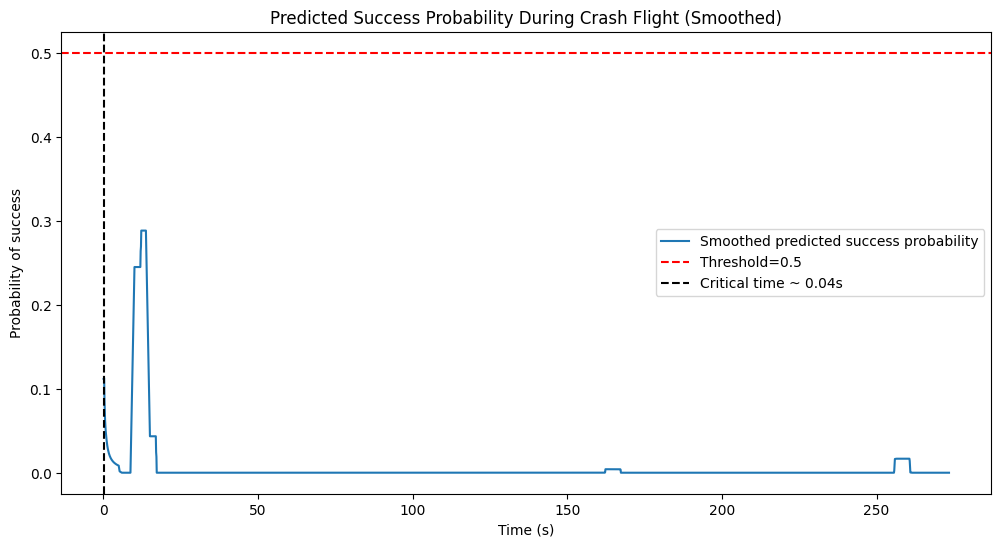

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert predicted probabilities to a Series
y_prob_series = pd.Series(y_prob_crash.flatten())

# Apply rolling average (window=50, adjust as needed)
y_prob_smooth = y_prob_series.rolling(window=50, min_periods=1).mean()

plt.figure(figsize=(12,6))
plt.plot(crash_df["t__s"], y_prob_smooth, label="Smoothed predicted success probability")
plt.axhline(y=0.5, color='r', linestyle='--', label='Threshold=0.5')

# Critical time
below_threshold = crash_df["t__s"][y_prob_smooth < 0.5]
if len(below_threshold) > 0:
    critical_time = below_threshold.iloc[0]
    plt.axvline(x=critical_time, color='k', linestyle='--', label=f'Critical time ~ {critical_time:.2f}s')

plt.xlabel("Time (s)")
plt.ylabel("Probability of success")
plt.title("Predicted Success Probability During Crash Flight (Smoothed)")
plt.legend()
plt.show()
